Angular Shift (Exaggerated): 5.00 units on star map


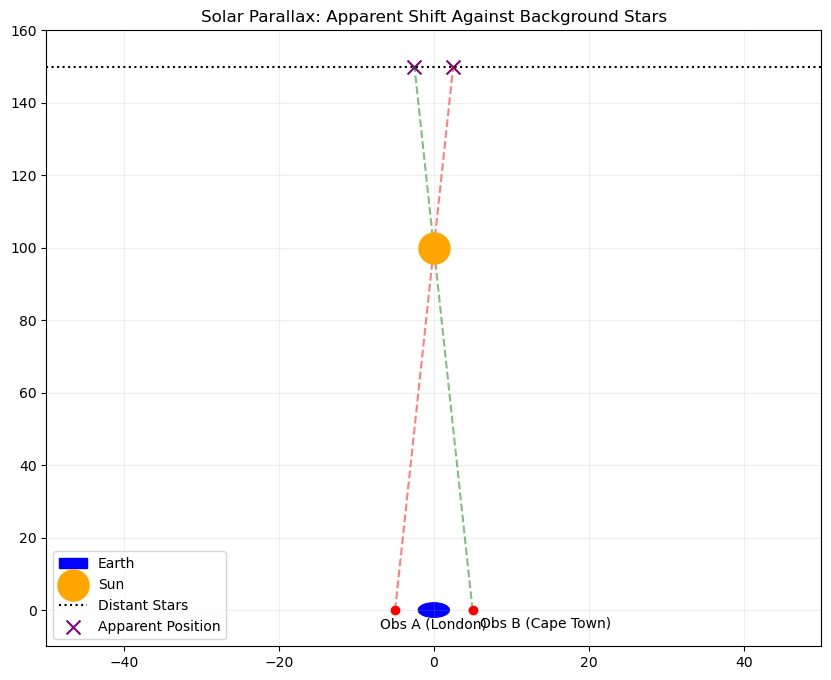

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def draw_parallax_demo():
    # 1. Setup Coordinates
    # Sun is at (0, 100), Earth is near the origin (0,0)
    sun_pos = np.array([0, 100])
    background_stars_y = 150
    
    # Observer positions (Left and Right sides of Earth)
    obs_a = np.array([-5, 0])
    obs_b = np.array([5, 0])
    
    # 2. Calculate the projection onto background stars
    # Line equation: y = mx + c. We find where the line through Obs and Sun hits y=150
    def get_projection(obs, sun):
        slope = (sun[1] - obs[1]) / (sun[0] - obs[0])
        # x = (y - y1)/m + x1
        x_proj = (background_stars_y - obs[1]) / slope + obs[0]
        return x_proj

    proj_a = get_projection(obs_a, sun_pos)
    proj_b = get_projection(obs_b, sun_pos)

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Draw Earth (simplified)
    earth = plt.Circle((0, 0), 2, color='blue', label='Earth')
    ax.add_artist(earth)
    
    # Draw Observers
    plt.scatter([obs_a[0], obs_b[0]], [obs_a[1], obs_b[1]], color='red', zorder=5)
    plt.text(obs_a[0]-2, -5, "Obs A (London)")
    plt.text(obs_b[0]+1, -5, "Obs B (Cape Town)")

    # Draw Sun
    plt.scatter(sun_pos[0], sun_pos[1], s=500, color='orange', label='Sun', zorder=5)
    
    # Draw Sight Lines
    plt.plot([obs_a[0], proj_a], [obs_a[1], background_stars_y], 'r--', alpha=0.5)
    plt.plot([obs_b[0], proj_b], [obs_b[1], background_stars_y], 'g--', alpha=0.5)

    # Draw Background Stars line
    plt.axhline(background_stars_y, color='black', linestyle=':', label='Distant Stars')
    plt.scatter([proj_a, proj_b], [background_stars_y, background_stars_y], 
                color='purple', marker='x', s=100, label='Apparent Position')

    # Formatting
    plt.title("Solar Parallax: Apparent Shift Against Background Stars")
    plt.xlim(-50, 50)
    plt.ylim(-10, 160)
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    print(f"Angular Shift (Exaggerated): {abs(proj_a - proj_b):.2f} units on star map")
    plt.show()

if __name__ == "__main__":
    draw_parallax_demo()